# 🧠 Section 10. YOLO와 Object Detection 성능 평가
## CNN 구조와 영상 데이터 처리 실습

---
### 📌 이 노트북에서 배우는 것
- 1-Stage(SSDLite)와 2-Stage(Faster R-CNN) 탐지기의 추론 속도를 직접 비교한다
- Precision, Recall을 계산하고 Confidence Threshold 변화에 따른 트레이드오프를 확인한다
- Precision-Recall 곡선을 그리고 AP를 계산한다
- 두 모델의 탐지 결과를 동일 이미지에 나란히 시각화하고 차이를 분석한다

### 📦 사용 데이터셋
| 항목 | 내용 |
|------|------|
| 이름 | matplotlib 내장 샘플 이미지 |
| 모델 | COCO 사전학습 Faster R-CNN + SSDLite |

## ⚙️ 실습 전 필수 확인
```bash
conda env create -f environment.yml
conda activate cnn-course
jupyter lab
```

In [1]:
# ⚙️ 환경 설정
import torch, torchvision
from torchvision.ops import nms, box_iou
from torchvision.models.detection import (
    fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights,
    ssdlite320_mobilenet_v3_large, SSDLite320_MobileNet_V3_Large_Weights
)
import matplotlib.pyplot as plt, matplotlib.patches as patches
import numpy as np, time

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {device} | PyTorch: {torch.__version__}")

✅ Device: cpu | PyTorch: 2.11.0+cpu


In [2]:
# ✅ 로컬 방식
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

nanum_fonts = [f for f in fm.fontManager.ttflist if 'Nanum' in f.name]

if nanum_fonts:
    font_path = nanum_fonts[0].fname          # 폰트 파일 경로 추출
    font_name = fm.FontProperties(fname=font_path).get_name()  # 실제 등록 이름 확인
    plt.rcParams['font.family'] = font_name
    print(f"✅ 적용 폰트: {font_name}")
else:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    print("⚠️ 나눔 폰트 없음 → 맑은 고딕 적용")

plt.rcParams['axes.unicode_minus'] = False

⚠️ 나눔 폰트 없음 → 맑은 고딕 적용


---
## 실습 1. 두 모델 로드 및 구조 비교

1-Stage(SSDLite)와 2-Stage(Faster R-CNN)를 모두 로드하고  
파라미터 수와 아키텍처를 비교합니다.

In [3]:
# ─────────────────────────────────────────────
# 1-1. 두 모델 로드
# ─────────────────────────────────────────────

print("모델 로드 중...")
w_rcnn = FasterRCNN_ResNet50_FPN_Weights.COCO_V1
w_ssd  = SSDLite320_MobileNet_V3_Large_Weights.COCO_V1

rcnn = fasterrcnn_resnet50_fpn(weights=w_rcnn).eval().to(device)
ssd  = ssdlite320_mobilenet_v3_large(weights=w_ssd).eval().to(device)

COCO_LABELS = w_rcnn.meta['categories']

rcnn_params = sum(p.numel() for p in rcnn.parameters())
ssd_params  = sum(p.numel() for p in ssd.parameters())

print(f"\n{'모델':<20} {'파라미터 수':>15} {'타입'}")
print("-" * 45)
print(f"{'Faster R-CNN':<20} {rcnn_params:>15,}  2-Stage")
print(f"{'SSDLite':<20} {ssd_params:>15,}  1-Stage (경량)")
print(f"\nFaster R-CNN이 SSDLite보다 {rcnn_params/ssd_params:.1f}배 더 많은 파라미터")
print("💡 일반적으로 파라미터가 많을수록 정확하지만 느립니다.")

모델 로드 중...
Downloading: "https://download.pytorch.org/models/ssdlite320_mobilenet_v3_large_coco-a79551df.pth" to C:\Users\hanmi/.cache\torch\hub\checkpoints\ssdlite320_mobilenet_v3_large_coco-a79551df.pth


100.0%



모델                            파라미터 수 타입
---------------------------------------------
Faster R-CNN              41,755,286  2-Stage
SSDLite                    3,440,060  1-Stage (경량)

Faster R-CNN이 SSDLite보다 12.1배 더 많은 파라미터
💡 일반적으로 파라미터가 많을수록 정확하지만 느립니다.


---
## 실습 2. 추론 속도 비교

### 📖 왜 1-Stage가 빠른가?

| 모델 | 처리 흐름 | 큰 연산 횟수 |
|---|---|---|
| 2-Stage (Faster R-CNN) | 이미지 → Backbone → RPN → 300개 ROI 각각 처리 | 2번 |
| 1-Stage (SSDLite) | 이미지 → Backbone → Head 직접 출력 | **1번** |

> 💡 **핵심 직관**  
> 2-Stage는 "먼저 수상한 곳을 300군데 찍어두고, 각각 정밀 검사"하는 방식입니다.  
> 1-Stage는 "한 번에 전체를 훑으며 바로 판정"하는 방식입니다.  
> 당연히 1-Stage가 빠르지만, 세밀한 검사가 없으니 작은 객체는 놓칠 수 있습니다.

> ⚠️ **GPU 시간 측정 주의**: GPU는 비동기 처리를 하기 때문에  
> `time.time()`만으로는 정확한 시간이 안 나옵니다.  
> GPU 사용 시 `torch.cuda.synchronize()` 호출 후 시간을 측정해야 합니다.

In [4]:
# ─────────────────────────────────────────────
# 2-1. 이미지 준비
# ─────────────────────────────────────────────

img_np = plt.imread(plt.matplotlib.cbook.get_sample_data('grace_hopper.jpg'))
img_t  = torchvision.transforms.functional.to_tensor(img_np).unsqueeze(0).to(device)
print(f"이미지 shape: {img_np.shape}")
print(f"텐서 shape:  {img_t.shape}")

c:\Users\hanmi\miniconda3\envs\cnn-course\lib\site-packages\torchvision\transforms\functional.py:154: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  img = torch.from_numpy(pic.transpose((2, 0, 1))).contiguous()


이미지 shape: (600, 512, 3)
텐서 shape:  torch.Size([1, 3, 600, 512])


In [5]:
# ─────────────────────────────────────────────
# 2-2. 추론 시간 측정
# ─────────────────────────────────────────────
# ⚠️ 처음 1회는 모델 초기화 오버헤드가 있으므로 여러 번 평균을 냅니다.

N_RUNS = 5

# 워밍업 (처음 한 번은 초기화 시간 포함)
with torch.no_grad():
    _ = rcnn(img_t); _ = ssd(img_t)

# 실제 시간 측정
times = {}
for name, model in [("Faster R-CNN", rcnn), ("SSDLite", ssd)]:
    if device.type == 'cuda':
        torch.cuda.synchronize()   # GPU 연산 완료 대기
    start = time.time()
    with torch.no_grad():
        for _ in range(N_RUNS):
            _ = model(img_t)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = (time.time() - start) / N_RUNS * 1000   # ms 단위
    times[name] = elapsed
    print(f"{name:<15}: {elapsed:.1f} ms/이미지  ({1000/elapsed:.1f} FPS)")

print(f"\n속도 비율: SSDLite가 Faster R-CNN보다 {times['Faster R-CNN']/times['SSDLite']:.1f}배 빠름")
print("💡 실시간(30 FPS) 처리가 필요하면 1-Stage가 유리합니다.")

Faster R-CNN   : 1425.7 ms/이미지  (0.7 FPS)
SSDLite        : 71.8 ms/이미지  (13.9 FPS)

속도 비율: SSDLite가 Faster R-CNN보다 19.9배 빠름
💡 실시간(30 FPS) 처리가 필요하면 1-Stage가 유리합니다.


---
## 실습 3. Precision과 Recall — 탐지 성능 측정

### 📖 왜 정확도(Accuracy)를 쓰지 않나?

탐지에서 단순 정확도는 의미가 없습니다. 예를 들어:
- 이미지에 고양이가 3마리 있는데 0마리를 탐지했다면?
  → "배경은 다 맞췄으니" 정확도가 높게 나올 수 있음

탐지 평가에는 더 정교한 지표가 필요합니다.

### 📖 핵심 개념

| 상황 | 판정 | 직관적 의미 |
|---|---|---|
| 박스 있고 클래스 맞고 IoU≥0.5 | TP | 올바른 탐지 |
| 박스 있는데 틀림 또는 IoU<0.5 | FP | 헛탐지 |
| 실제 객체를 탐지 못함 | FN | 놓침 |

```
Precision = TP / (TP + FP)  → "내가 탐지한 것 중 진짜 비율"
Recall    = TP / (TP + FN)  → "실제 객체 중 내가 찾은 비율"
```

> 💡 **트레이드오프**  
> Confidence threshold를 높이면: 확실한 것만 탐지 → Precision↑ Recall↓  
> Confidence threshold를 낮추면: 많이 탐지 → Precision↓ Recall↑  
> AP는 이 트레이드오프 전체를 하나의 숫자로 요약합니다.

In [6]:
# ─────────────────────────────────────────────
# 3-1. Precision·Recall 계산 완성 예시 — 먼저 실행
# ─────────────────────────────────────────────

def precision_recall_example(pred_boxes, pred_scores, gt_boxes, iou_thresh=0.5):
    """
    단일 이미지의 Precision-Recall 포인트를 계산합니다. (완성 예시)

    Args:
        pred_boxes (Tensor): (M, 4) 예측 박스 (점수 내림차순)
        pred_scores(Tensor): (M,) 예측 신뢰도
        gt_boxes   (Tensor): (N, 4) 정답 박스
        iou_thresh (float): TP 판정 기준

    Returns:
        tuple: (precision 배열, recall 배열)
    """
    if len(gt_boxes) == 0:
        return np.array([]), np.array([])

    # 신뢰도 내림차순 정렬
    order = pred_scores.argsort(descending=True)
    pred_boxes = pred_boxes[order]

    matched_gt = set()
    tp_list, fp_list = [], []

    for p_box in pred_boxes:
        ious = box_iou(p_box.unsqueeze(0), gt_boxes).squeeze(0)
        best_iou, best_idx = ious.max(0) if len(gt_boxes) > 0 else (torch.tensor(0.), torch.tensor(0))

        if best_iou >= iou_thresh and best_idx.item() not in matched_gt:
            tp_list.append(1); fp_list.append(0)
            matched_gt.add(best_idx.item())
        else:
            tp_list.append(0); fp_list.append(1)

    tp = np.cumsum(tp_list)
    fp = np.cumsum(fp_list)
    precision = tp / (tp + fp)
    recall    = tp / len(gt_boxes)
    return precision, recall

# 예시: 3개 정답, 4개 예측
gt   = torch.tensor([[10.,10.,60.,60.],[100.,20.,160.,80.],[50.,100.,120.,160.]])
pred = torch.tensor([[12.,12.,58.,58.],[100.,20.,160.,80.],[200.,200.,250.,250.],[52.,102.,118.,158.]])
scores = torch.tensor([0.9, 0.85, 0.6, 0.7])

prec, rec = precision_recall_example(pred, scores, gt)
print("threshold별 Precision / Recall:")
for i,(p,r) in enumerate(zip(prec,rec)):
    print(f"  박스 {i+1}개 평가 후: Precision={p:.3f}, Recall={r:.3f}")

threshold별 Precision / Recall:
  박스 1개 평가 후: Precision=1.000, Recall=0.333
  박스 2개 평가 후: Precision=1.000, Recall=0.667
  박스 3개 평가 후: Precision=1.000, Recall=1.000
  박스 4개 평가 후: Precision=0.750, Recall=1.000


### ✏️ 이제 AP 계산을 직접 구현해봅시다

In [ ]:
# ─────────────────────────────────────────────
# 3-2. ✏️ TODO: AP(Average Precision) 계산
# ─────────────────────────────────────────────
# AP = PR 곡선 아래 넓이 (11-point interpolation)

def compute_ap(precision, recall):
    """
    11-point interpolation으로 AP를 계산합니다.
    recall 0.0, 0.1, 0.2, ..., 1.0의 11개 지점에서
    precision의 최댓값을 구하여 평균냅니다.

    Args:
        precision (np.ndarray): precision 배열
        recall    (np.ndarray): recall 배열 (오름차순)

    Returns:
        float: Average Precision (0~1)
    """
    if len(precision) == 0:
        return 0.0

    ap = 0.0
    for t in np.linspace(0, 1, 11):   # 0.0, 0.1, ..., 1.0
        # recall >= t 인 구간에서 precision의 최댓값
        prec_at_t = precision[___ >= t]   # 힌트: recall 배열과 비교
        ap += prec_at_t.max() if ___ > 0 else 0.0   # 힌트: len(prec_at_t)

    return ap / 11   # 11개 지점의 평균

print("compute_ap를 완성한 뒤 다음 셀을 실행하세요!")

In [7]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
def compute_ap(precision, recall):
    if len(precision)==0: return 0.0
    ap=0.0
    for t in np.linspace(0,1,11):
        prec_at_t=precision[recall>=t]
        ap+=prec_at_t.max() if len(prec_at_t)>0 else 0.0
    return ap/11
print("✅ compute_ap 정답 로드!")

✅ compute_ap 정답 로드!


AP@0.5 = 1.0000


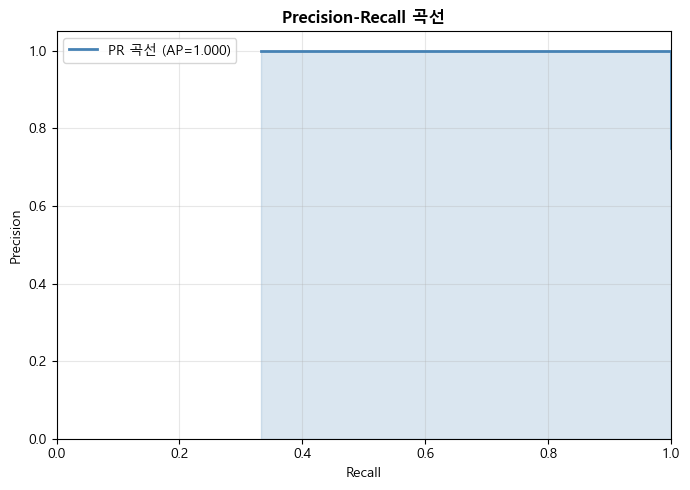

In [8]:
# AP 계산 및 PR 곡선 시각화
ap = compute_ap(prec, rec)
print(f"AP@0.5 = {ap:.4f}")

plt.figure(figsize=(7, 5))
plt.step(rec, prec, where='post', color='steelblue', lw=2, label=f'PR 곡선 (AP={ap:.3f})')
plt.fill_between(rec, prec, alpha=0.2, color='steelblue')
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall 곡선", fontweight='bold')
plt.xlim([0,1]); plt.ylim([0,1.05])
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## 실습 4. Faster R-CNN vs SSDLite 결과 비교

같은 이미지에 두 모델을 적용하고 결과를 나란히 시각화합니다.  
Confidence Threshold에 따른 탐지 결과 변화도 함께 확인합니다.

Faster R-CNN 탐지 수 (score>0.4): 3개
SSDLite 탐지 수 (score>0.4):     1개


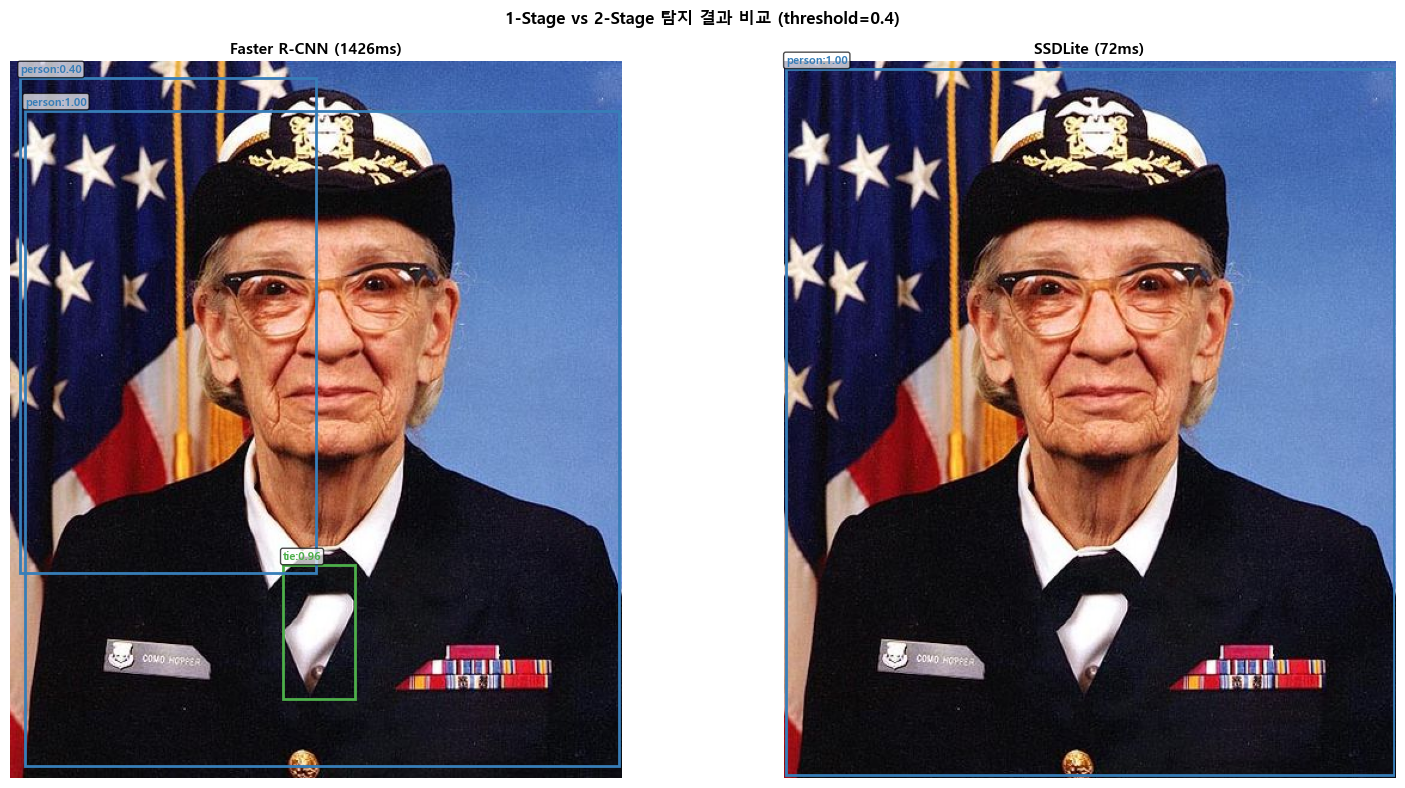

In [9]:
# ─────────────────────────────────────────────
# 4-1. 두 모델 추론 결과 비교
# ─────────────────────────────────────────────

with torch.no_grad():
    pred_rcnn = rcnn(img_t)[0]
    pred_ssd  = ssd(img_t)[0]

THRESHOLD = 0.4

def get_filtered(pred, threshold):
    mask = pred['scores'] > threshold
    return pred['boxes'][mask].cpu(), pred['scores'][mask].cpu(), pred['labels'][mask].cpu()

b_rcnn, s_rcnn, l_rcnn = get_filtered(pred_rcnn, THRESHOLD)
b_ssd,  s_ssd,  l_ssd  = get_filtered(pred_ssd,  THRESHOLD)

print(f"Faster R-CNN 탐지 수 (score>{THRESHOLD}): {len(b_rcnn)}개")
print(f"SSDLite 탐지 수 (score>{THRESHOLD}):     {len(b_ssd)}개")

# 나란히 시각화
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
color_map = plt.cm.Set1(np.linspace(0,1,10))

for ax, (boxes_f, scores_f, labels_f, model_name, t) in zip(axes, [
    (b_rcnn, s_rcnn, l_rcnn, f"Faster R-CNN ({times['Faster R-CNN']:.0f}ms)", times['Faster R-CNN']),
    (b_ssd,  s_ssd,  l_ssd,  f"SSDLite ({times['SSDLite']:.0f}ms)", times['SSDLite']),
]):
    ax.imshow(img_np)
    for box, score, label in zip(boxes_f, scores_f, labels_f):
        x1,y1,x2,y2 = box.tolist()
        c = color_map[label.item() % 10]
        rect = patches.Rectangle((x1,y1),(x2-x1),(y2-y1),lw=2,edgecolor=c,facecolor='none')
        ax.add_patch(rect)
        cls = COCO_LABELS[label.item()] if label.item()<len(COCO_LABELS) else str(label.item())
        ax.text(x1,y1-5,f"{cls}:{score:.2f}",color=c,fontsize=8,fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2',facecolor='white',alpha=0.7))
    ax.set_title(model_name, fontsize=11, fontweight='bold'); ax.axis('off')

plt.suptitle(f"1-Stage vs 2-Stage 탐지 결과 비교 (threshold={THRESHOLD})", fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

threshold=0.2: RCNN=9개, SSD=1개
threshold=0.4: RCNN=3개, SSD=1개
threshold=0.6: RCNN=2개, SSD=1개
threshold=0.8: RCNN=2개, SSD=1개


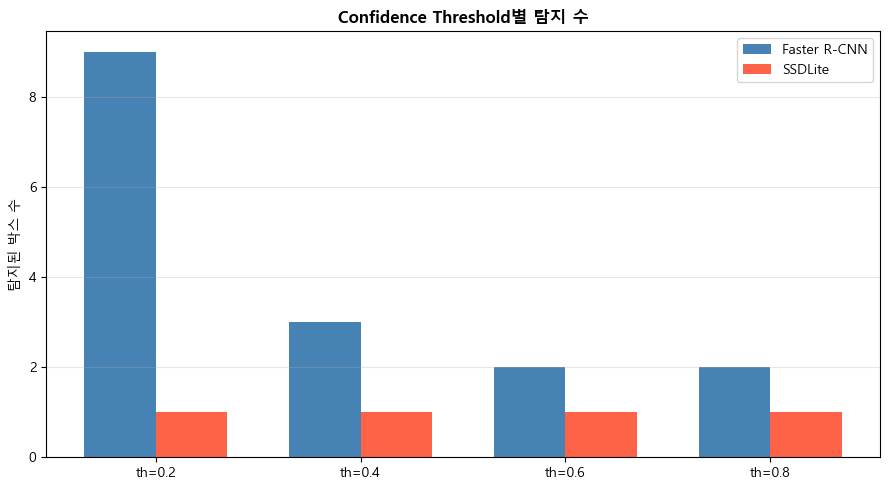

💡 threshold가 높아질수록 탐지 수 감소 → Precision↑ Recall↓


In [ ]:
# ─────────────────────────────────────────────
# 4-2. ✏️ 빈칸: Confidence Threshold 변화에 따른 탐지 수 분석
# ─────────────────────────────────────────────

thresholds = [0.2, 0.4, 0.6, 0.8]
counts_rcnn = []
counts_ssd  = []

for th in thresholds:
    # ✏️ 빈칸: 각 threshold에서 탐지된 박스 수를 계산하세요
    n_rcnn = (pred_rcnn['scores'] ___ th).sum().item()   # 힌트: > 비교 연산
    n_ssd  = (pred_ssd['scores']  ___ th).sum().item()
    counts_rcnn.append(n_rcnn)
    counts_ssd.append(n_ssd)
    print(f"threshold={th}: RCNN={n_rcnn}개, SSD={n_ssd}개")

# 시각화
x = np.arange(len(thresholds))
width = 0.35
fig, ax = plt.subplots(figsize=(9,5))
ax.bar(x - width/2, counts_rcnn, width, label='Faster R-CNN', color='steelblue')
ax.bar(x + width/2, counts_ssd,  width, label='SSDLite',      color='tomato')
ax.set_xticks(x); ax.set_xticklabels([f"th={t}" for t in thresholds])
ax.set_ylabel("탐지된 박스 수"); ax.set_title("Confidence Threshold별 탐지 수", fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
print("💡 threshold가 높아질수록 탐지 수 감소 → Precision↑ Recall↓")

In [ ]:
# 💡 정답 확인 (먼저 스스로 풀어보세요!)
# -------------------------------------------
# n_rcnn = (pred_rcnn['scores'] > th).sum().item()
# n_ssd  = (pred_ssd['scores']  > th).sum().item()
print("n_rcnn = (pred_rcnn['scores'] > th).sum().item()")

---
## 실습 5. 1-Stage vs 2-Stage 종합 정리

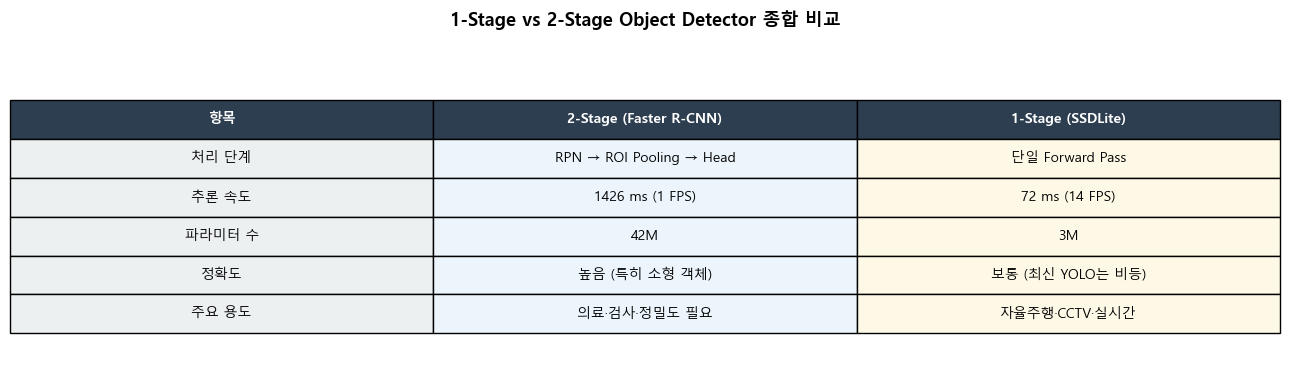

In [12]:
# ─────────────────────────────────────────────
# 5-1. 종합 비교표 시각화
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')

comparison = [
    ["항목", "2-Stage (Faster R-CNN)", "1-Stage (SSDLite)"],
    ["처리 단계", "RPN → ROI Pooling → Head", "단일 Forward Pass"],
    ["추론 속도", f"{times['Faster R-CNN']:.0f} ms ({1000/times['Faster R-CNN']:.0f} FPS)",
                  f"{times['SSDLite']:.0f} ms ({1000/times['SSDLite']:.0f} FPS)"],
    ["파라미터 수", f"{rcnn_params/1e6:.0f}M", f"{ssd_params/1e6:.0f}M"],
    ["정확도", "높음 (특히 소형 객체)", "보통 (최신 YOLO는 비등)"],
    ["주요 용도", "의료·검사·정밀도 필요", "자율주행·CCTV·실시간"],
]

table = ax.table(cellText=comparison[1:], colLabels=comparison[0],
                  loc='center', cellLoc='center')
table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1, 2.2)
for (r,c), cell in table.get_celld().items():
    if r==0:
        cell.set_facecolor('#2C3E50'); cell.set_text_props(color='white', fontweight='bold')
    elif c==0:
        cell.set_facecolor('#ECF0F1')
    elif c==1:
        cell.set_facecolor('#EBF5FB')
    else:
        cell.set_facecolor('#FEF9E7')

plt.title("1-Stage vs 2-Stage Object Detector 종합 비교", fontsize=13, fontweight='bold', pad=20)
plt.tight_layout(); plt.show()

---
## 🚀 도전 과제

### 과제 1. mAP 계산
`compute_ap` 함수를 클래스별로 적용하고  
전체 클래스의 AP 평균(mAP)을 계산하는 `compute_map` 함수를 완성하세요.

### 과제 2. 오탐지·미탐지 분석
threshold=0.5 기준으로 두 모델의 결과를 비교하여  
"Faster R-CNN은 찾았지만 SSDLite가 놓친 객체"를 찾아 시각화하세요.

### 과제 3. 비디오 FPS 시뮬레이션
`torch.stack`으로 10장짜리 가상 배치를 만들어  
배치 추론 시 실제 처리 가능한 FPS를 계산하고 비교하세요.
